In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
digits = load_digits()
X = torch.FloatTensor(digits.data).view(-1, 1, 8, 8) / 16.0
y = torch.LongTensor(digits.target)
X, y = X.to(device), y.to(device)

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(8 * 4 * 4, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

In [4]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
for epoch in range(20):
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()

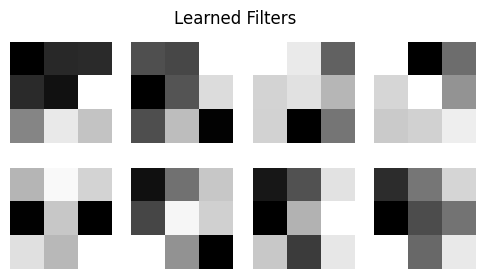

In [5]:
filters = model.conv1.weight.data.clone().cpu()
filters = filters - filters.min()
filters = filters / filters.max()
fig, axs = plt.subplots(2, 4, figsize=(6, 3))
for i in range(8):
    axs[i//4, i%4].imshow(filters[i, 0].numpy(), cmap='gray')
    axs[i//4, i%4].axis('off')
plt.suptitle('Learned Filters')
plt.savefig('digits_cnn_filters.png')